# Chapter 7, Exercise 4: Auditing an Arabic corpus for dialect and gender imbalance

> **How to use this notebook.** Open it in Google Colab (File > Upload notebook, or the Colab badge on the companion website), then run the cells from top to bottom. Runtime > Change runtime type lets you pick a GPU when one is recommended below. Everything else runs on the free CPU tier.

## The exercise

**Chapter 7, Exercise 4.** Audit a public Arabic corpus for bias: extract its metadata and compute the hours-per-speaker ratio for each dialect and for each gender where available, identify the group with the largest deficit, and propose a concrete sampling or reweighting strategy to reduce that imbalance. If the corpus does not expose gender or dialect metadata, state that limitation explicitly and audit only the fields that are available.

**Note on data.** The audit function below works on any metadata table. Three sources are wired in: (A) the official **SADA** CSV files from Kaggle (login required; the notebook explains how to upload them); (B) a community-redistributed SADA2022 subset on the Hugging Face Hub (no login; dialect, gender and environment fields but no speaker identifier); (C) the **FLEURS** Arabic TSVs (no login; gender only). Path B is the default so that the notebook runs anywhere; it audits a *sample*, not the corpus, and says so.

## Requirements

No GPU is required; the notebook runs on Colab's free CPU runtime.

## Testing status

Paths B (SADA Hub subset) and C (FLEURS) were executed. Path A (official SADA CSVs from Kaggle) uses the same code but was not executed here because it requires a Kaggle login; column detection is keyword-based, so check the printed `fields available` line.


<a href="https://colab.research.google.com/github/arabic-speech-book/arabic-speech-book.github.io/blob/main/docs/solutions/Chapter_07_Exercise_04.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

In [1]:
!pip install -q pandas huggingface_hub pyarrow matplotlib

## 1. Load a metadata table

Every path ends with a DataFrame `meta` holding one row per segment and, where available, the columns `duration_s`, `speaker`, `dialect`, `gender`. Missing fields are recorded in `AVAILABLE` and the audit skips them.

In [2]:
import os, io, re, numpy as np, pandas as pd
SOURCE = os.environ.get("AUDIT_SOURCE", "sada_hf_subset")   # "sada_kaggle", "sada_hf_subset", or "fleurs"
AVAILABLE = {}

def find_col(df, *keywords):
    for c in df.columns:
        if all(k.lower() in c.lower() for k in keywords): return c
    return None

if SOURCE == "sada_kaggle":
    # Download SADA from https://www.kaggle.com/datasets/sdaiancai/sada2022 (accept the licence), then upload
    # the CSV metadata files (e.g. train.csv, valid.csv, test.csv). Column names are detected by keyword.
    try:
        from google.colab import files; files.upload()
    except ImportError:
        pass
    frames = [pd.read_csv(f) for f in os.listdir(".") if f.endswith(".csv")]
    raw = pd.concat(frames, ignore_index=True)
    LABEL = "SADA official release (Kaggle CSVs)"
elif SOURCE == "sada_hf_subset":
    from huggingface_hub import hf_hub_download
    import pyarrow.parquet as pq
    p = hf_hub_download("SarahUssama/sada-arabic-test-dataset-sample", "default/train/0000.parquet",
                        repo_type="dataset", revision="refs/convert/parquet")
    pf = pq.ParquetFile(p)
    raw = pf.read(columns=[c for c in pf.schema_arrow.names if c != "audio"]).to_pandas()
    LABEL = "SADA2022 community subset on the Hugging Face Hub (496 segments; NOT the full corpus)"
else:
    from huggingface_hub import hf_hub_download
    parts = []
    for split in ["train", "dev", "test"]:
        f = hf_hub_download("google/fleurs", f"data/ar_eg/{split}.tsv", repo_type="dataset")
        d = pd.read_csv(f, sep="\t", header=None, quoting=3,
                        names=["id", "file", "raw_transcription", "transcription", "chars", "num_samples", "gender"])
        d["split"] = split; parts.append(d)
    raw = pd.concat(parts, ignore_index=True)
    raw["duration_s"] = raw["num_samples"] / 16000.0
    LABEL = "FLEURS Arabic (ar_eg), all splits"

meta = pd.DataFrame(index=raw.index)
# duration
dur = find_col(raw, "duration") or find_col(raw, "SegmentLength")
if dur is None and find_col(raw, "SegmentStart") and find_col(raw, "SegmentEnd"):
    meta["duration_s"] = raw[find_col(raw, "SegmentEnd")] - raw[find_col(raw, "SegmentStart")]
elif dur is not None:
    meta["duration_s"] = raw[dur]
for field, keys in {"speaker": ["speaker", "id"], "dialect": ["dialect"], "gender": ["gender"]}.items():
    col = None
    for c in raw.columns:
        cl = c.lower()
        if field == "speaker" and ("speakerid" in cl.replace("_", "") or cl in ("speaker", "speaker_id", "spk")): col = c
        elif field != "speaker" and field in cl: col = c
    AVAILABLE[field] = col is not None
    if col is not None: meta[field] = raw[col].astype(str).str.strip()
print("Source:", LABEL); print("rows:", len(meta), "| total hours:", round(meta["duration_s"].sum()/3600, 2))
print("fields available:", AVAILABLE)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Source: SADA2022 community subset on the Hugging Face Hub (496 segments; NOT the full corpus)
rows: 496 | total hours: 0.46
fields available: {'speaker': False, 'dialect': True, 'gender': True}


## 2. The audit

For each available grouping field: hours, number of segments, number of distinct speakers (if a speaker field exists) and the **hours-per-speaker ratio** = hours / distinct speakers. The deficit is measured against the group with the most hours.

In [3]:
def audit(meta, field):
    g = meta.groupby(field)
    out = pd.DataFrame({"hours": g["duration_s"].sum()/3600, "segments": g.size()})
    if AVAILABLE.get("speaker"):
        out["speakers"] = g["speaker"].nunique()
        out["hours_per_speaker"] = out["hours"] / out["speakers"]
    out["share_of_hours_%"] = 100*out["hours"]/out["hours"].sum()
    out["deficit_vs_largest_h"] = out["hours"].max() - out["hours"]
    return out.sort_values("hours", ascending=False).round(3)

tables = {}
for field in ["dialect", "gender"]:
    if AVAILABLE.get(field):
        tables[field] = audit(meta, field); print(f"\n=== by {field} ==="); print(tables[field])
    else:
        print(f"\n=== by {field} === NOT AVAILABLE in this metadata; skipped (stated limitation)")
if AVAILABLE.get("dialect") and AVAILABLE.get("gender"):
    print("\n=== by dialect x gender (hours) ===")
    print((meta.groupby(["dialect", "gender"])["duration_s"].sum()/3600).round(3).unstack(fill_value=0))
if not AVAILABLE.get("speaker"):
    print("\nLIMITATION: no speaker identifier in this metadata, so hours PER SPEAKER cannot be computed; "
          "only hours per group are audited.")


=== by dialect ===
          hours  segments  share_of_hours_%  deficit_vs_largest_h
dialect                                                          
Saudi     0.303       300             66.43                  0.00
Egyptian  0.153       196             33.57                  0.15

=== by gender ===
        hours  segments  share_of_hours_%  deficit_vs_largest_h
gender                                                         
Male    0.355       397            77.975                 0.000
Female  0.100        99            22.025                 0.255

=== by dialect x gender (hours) ===
gender    Female   Male
dialect                
Egyptian   0.025  0.128
Saudi      0.075  0.228

LIMITATION: no speaker identifier in this metadata, so hours PER SPEAKER cannot be computed; only hours per group are audited.


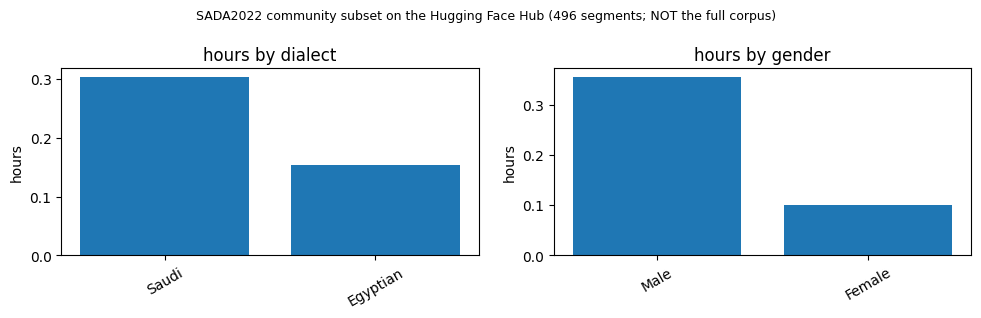

In [4]:
import matplotlib.pyplot as plt
n = len(tables)
if n:
    fig, ax = plt.subplots(1, n, figsize=(5*n, 3.2))
    ax = np.atleast_1d(ax)
    for a, (field, t) in zip(ax, tables.items()):
        a.bar(t.index, t["hours"]); a.set_title(f"hours by {field}"); a.set_ylabel("hours"); a.tick_params(axis='x', rotation=30)
    plt.suptitle(LABEL, fontsize=9); plt.tight_layout(); plt.show()

## 3. Identify the largest deficit and propose a remedy

The cell prints the group with the largest deficit for each field and computes **balancing weights**: the inverse of each group's share of hours, normalized so that the weighted training mix gives every group equal expected hours (for reweighting), together with the **oversampling factor** needed to raise each group to the largest group's hours (for resampling).

In [5]:
for field, t in tables.items():
    worst = t["hours"].idxmin()
    print(f"[{field}] largest deficit: '{worst}' with {t.loc[worst,'hours']:.2f} h "
          f"({t.loc[worst,'share_of_hours_%']:.1f} % of hours), {t.loc[worst,'deficit_vs_largest_h']:.2f} h below the largest group")
    w = (1.0 / t["share_of_hours_%"]); w = w / w.sum() * len(t)
    factor = t["hours"].max() / t["hours"]
    plan = pd.DataFrame({"hours": t["hours"], "reweight (loss/sampling weight)": w.round(2),
                         "oversample factor to match largest": factor.round(1)})
    print(plan, "\n")

[dialect] largest deficit: 'Egyptian' with 0.15 h (33.6 % of hours), 0.15 h below the largest group
          hours  reweight (loss/sampling weight)  \
dialect                                            
Saudi     0.303                             0.67   
Egyptian  0.153                             1.33   

          oversample factor to match largest  
dialect                                       
Saudi                                    1.0  
Egyptian                                 2.0   

[gender] largest deficit: 'Female' with 0.10 h (22.0 % of hours), 0.26 h below the largest group
        hours  reweight (loss/sampling weight)  \
gender                                           
Male    0.355                             0.44   
Female  0.100                             1.56   

        oversample factor to match largest  
gender                                      
Male                                   1.0  
Female                                 3.6   



## 4. Reading the result and the strategy

*On the default source (SADA Hub subset, tested run)* the dialect field holds two labels (Saudi about 18 minutes, Egyptian about 9 minutes) and the gender field shows about four times more male than female segments; there is no speaker identifier, so hours per speaker cannot be computed, which is stated as a limitation. On the official SADA CSVs the same code reports hours per speaker per dialect (Najdi, Hijazi, Khaliji, and so on) and per gender, which is the audit the exercise asks for.

*Strategy.* For the deficit group (in the subset, female speakers; in the full corpus typically the smaller dialects and female speakers within them):

1. **Sampling for training.** Do not discard majority data; instead draw training batches with **temperature sampling** over the group (probability proportional to hours^α with α about 0.5) or apply the oversample factors above (with speed perturbation and SpecAugment so that repeats differ). Cap the factor at about 4 to avoid memorizing a tiny group.
2. **Loss reweighting.** Multiply each utterance's loss by the reweight column so that every group contributes equally to the gradient; combine with, not instead of, per-group evaluation.
3. **Evaluation.** Build the development and test sets so that every group has enough *speakers* (not just hours) to report a per-group WER, and report the macro-average across groups beside the pooled number (Section 7.7).
4. **Collection.** Reweighting cannot create the acoustic variety that is missing (a group with 3 speakers stays a group with 3 speakers, however many times it is repeated); the audit's real output is a recording plan that targets new *speakers* in the deficit group.